# kNN Regression

Código desenvolvido na *Section 1.1: Linear Regression - kNN Regression* do curso [Harvard CS109x: Introduction to Data Science with Python](https://learning.edx.org/course/course-v1:HarvardX+CS109x+3T2024/home)

## Objetivo

Desenvolver um modelo simples com base no algoritmo K-nearest Neighbors para valores.

## kNN

O kNN é um algoritmo de aprendizado não paramétrico.

> Algoritmos de aprendizado não paramétricos são modelos de machine learning que não fazem suposições rígidas sobre a distribuição ou o formato matemático dos dados. Em vez de estimar um número fixo de parâmetros, eles se adaptam livremente à estrutura das informações, crescendo em complexidade conforme a base de dados

O Algoritmo funciona da seguinte forma:

- Dado um dataset D - (X1, y1) ,,, (Xn, yn)
- Para cada **novo X**
- Busca as **k** observações "mais próximas do novo X"
- O output é a média do y dessas observações mais semelhantes

### Links

[Advertising Dataset](https://www.kaggle.com/datasets/ashydv/advertising-dataset/code)

[IBM: O que é KNN](https://www.ibm.com/br-pt/think/topics/knn)

[An Introduction to Statistical Learning (1 Introduction, 3 - 3.1.3 Simple Linear Regression - Assessing the Accuracy of the Model)](https://www.statlearning.com/)

## Baixando e entendendo o dataset

O conjunto de dados contém observações relacionadas às **vendas de um produto específico** e aos orçamentos alocados em campanhas publicitárias para esse produto em três mídias: TV, rádio e jornal.

> O objetivo é prever as vendas de um determinado período com base nos investimentos realizados em cada uma das três mídias.

### Informações sobre o dataset

- O conjunto de dados possui 200 observações.
- Existem três variáveis independentes (x): `TV`, `Radio` e `Newspapper`.
- Existe uma variável dependente (y): `Sales`.
- Não foram identificados valores ausentes em nenhuma das observações.

In [34]:

# download dataset from kagglehub
import kagglehub
import pandas as pd

#path = kagglehub.dataset_download("your-path")

#df = pd.read_csv(path)
df = pd.read_csv("advertising.csv")
# entendendo o dataset
print(
    df.head(),
    df.info(),
    df.describe(),
    df.shape
)

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9 None                TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.10000

## KNN - Preparo

Para construir um modelo com base no algoritmo kNN, vou selecionar apenas **UMA** variável independente (orçamento de propagandas para a TV), para então tentarmos prever as vendas levando em somente ELA em concideração.

Text(0, 0.5, 'Sales')

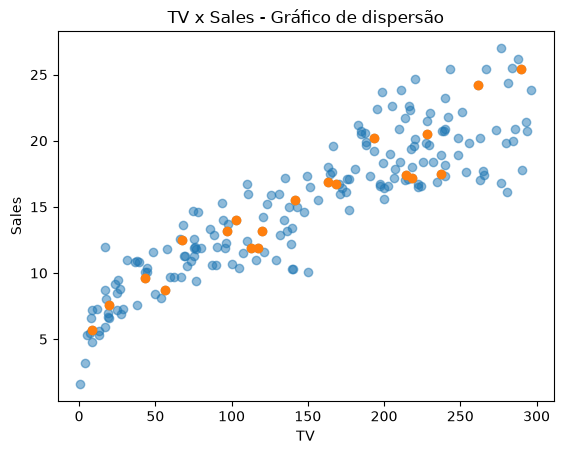

In [35]:
import matplotlib.pyplot as plt

x = df['TV']
y = df['Sales']

# separando amostras de 10% do dataset para x e y.
# O parâmetro random_state é usado para garantir que a amostra seja a mesma em diferentes execuções do código.
sample_x = x.sample(frac=.1, random_state=12)
sample_y = y.sample(frac=.1, random_state=12)

# o gráfico de dispersão
plt.scatter(x, y, alpha=0.5)
plt.scatter(sample_x, sample_y)
plt.title('TV x Sales - Gráfico de dispersão')
plt.xlabel('TV')
plt.ylabel('Sales')

## Código kNN

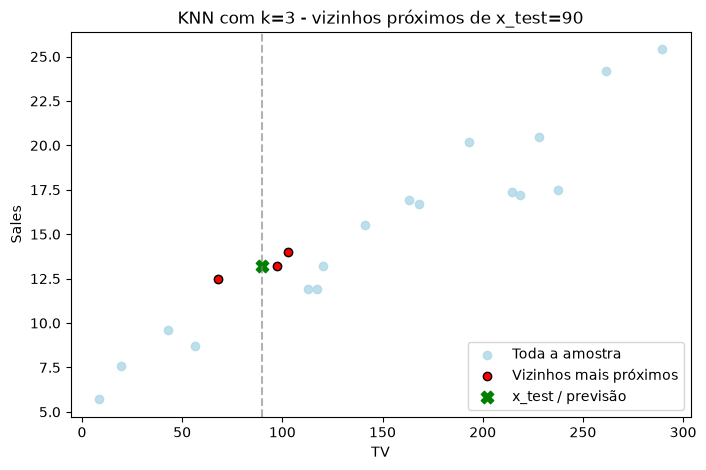

np.float64(13.233333333333334)

In [36]:
def knn(k, X_train, Y_train, x_test, plot: bool = True):
    """
    Função que implementa o algoritmo KNN (K-Nearest Neighbors) para regressão.

    Parâmetros:
    k: número de vizinhos mais próximos a serem considerados.
    X_train: série pandas contendo os dados de treinamento (variável independente).
    Y_train: série pandas contendo os dados de treinamento (variável dependente).
    x_test: valor de entrada para o qual se deseja fazer a previsão.
    plot: booleano indicando se deve ser plotado o gráfico do funcionamento do algoritmo.
    """

    # verificando se os dados de treinamento têm o mesmo tamanho e índices
    if (len(X_train) != len(Y_train)):
        raise ValueError("X_train and Y_train must have the same length")
    if (X_train.index != Y_train.index).any():
        raise ValueError("X_train and Y_train must have the same indexes")
    
    # calcula a distância de cada ponto ao valor de teste
    distances = pd.Series([abs(x - x_test) for x in X_train], index=X_train.index)

    # ordena as distâncias e seleciona os k vizinhos mais próximos
    distances_sorted = distances.sort_values()
    result_indexes = distances_sorted.index[:k]
    # calcula a média dos valores de Y correspondentes aos k vizinhos mais próximos
    prediction = Y_train.loc[result_indexes].mean()

    # visualização do funcionamento do algoritmo
    if plot:
        plt.figure(figsize=(8, 5))
        plt.scatter(X_train, Y_train, alpha=0.8, color='lightblue', label='Toda a amostra')
        plt.scatter(X_train.loc[result_indexes], Y_train.loc[result_indexes],
                    color='red', edgecolor='black', label='Vizinhos mais próximos')
        plt.scatter(x_test, prediction, color='green', marker='X', s=80,
                    label='x_test / previsão')
        plt.axvline(x_test, color='gray', linestyle='--', alpha=0.6)
        plt.title(f'KNN com k={k} - vizinhos próximos de x_test={x_test}')
        plt.xlabel('TV')
        plt.ylabel('Sales')
        plt.legend()
        plt.show()

    return prediction
        
knn(3, sample_x, sample_y, 90)

Previsão para x_test=10: 8.819999999999999
Previsão para x_test=100: 12.84
Previsão para x_test=200: 19.360000000000003


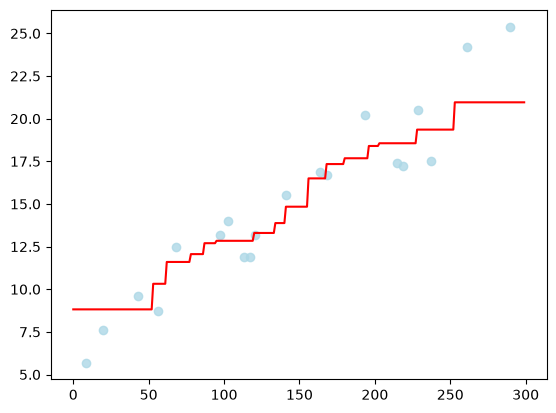

In [ ]:
model = pd.Series([knn(3, sample_x, sample_y, x_test, False) for x_test in range(0, 300)])
plt.Figure(figsize=(8, 5))
plt.scatter(sample_x, sample_y, alpha=0.8, color='lightblue', label='Toda a amostra')
plt.plot(model, color='red', label='Previsão KNN')

print(f"Previsão para x_test=10: {model[10]}")
print(f"Previsão para x_test=100: {model[100]}")
print(f"Previsão para x_test=200: {model[250]}")